<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/main/lab_ch21_diagnostic_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'dd6d1eee7919ddf744060754fd1c114b'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 34.5 MB/s eta 0:00:00
Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

### Error 1: Wrong differencing specification

The pipeline fits `ARIMA(..., d=0)` to raw CPI even though the ADF test indicates that CPI is non-stationary. This is a specification error because ARIMA requires differencing when the series has a unit root. If `d=0` is used on a non-stationary series, the mean process is misspecified and the forecasts become unreliable.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.DatetimeIndex(cpi.index)
cpi.index.freq = 'MS'
cpi.name = 'CPI'

# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi, autolag='AIC', regression='ct')
print(f'ADF test on raw CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# ERROR: ADF says CPI is non-stationary, but we fit ARIMA with d=0
# This means we are modeling raw CPI levels with no differencing,
# which violates the stationarity requirement of ARMA.
model = ARIMA(cpi, order=(2, 0, 1))  # d=0 ignores the unit root!
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi.plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,0,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,0,1) on Raw CPI — Something Is Wrong', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

ValueError: Inferred frequency None from passed values does not conform to passed frequency MS

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.

model_v2 = ARIMA(cpi, order=(2, 1, 1))  # d=1 is better, but no seasonal terms!
result_v2 = model_v2.fit()

# Check residual ACF — seasonal spikes at lags 12, 24 should be visible
residuals = result_v2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of ARIMA(2,1,1) Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of ARIMA(2,1,1) Residuals')
plt.tight_layout()
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

### Error 2: Seasonality was ignored

After fixing differencing, the pipeline still uses a plain ARIMA model for monthly CPI data. Since CPI is monthly, the model should account for annual seasonality with period 12. Ignoring seasonality leaves residual autocorrelation at lags such as 12 and 24, which means the model has not captured the full structure of the series.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

# Jumping straight to forecast without diagnostic checks!
forecast_horizon = 24  # 24 months ahead
forecast = result_v2.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Forecast', color='#e74c3c', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast — But Are the Residuals Clean?', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

### Error 3: Missing residual diagnostic

The pipeline goes straight to forecasting without checking residual autocorrelation. A proper time series pipeline should run the Ljung-Box test before forecasting. If residuals are still autocorrelated, then the model is misspecified and the forecast intervals may be misleading.

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

ADF test on first-differenced CPI:
  Test statistic: -2.6640
  P-value: 0.0805
  Conclusion: NON-STATIONARY

ADF test on first + seasonal differenced CPI:
  Test statistic: -4.2916
  P-value: 0.0005
  Conclusion: Stationary


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



SARIMA model fitted successfully.
AIC: 614.31
BIC: 632.61

Ljung-Box test results:
      lb_stat     lb_pvalue
12  67.737756  8.466733e-10
24  70.291748  1.974802e-06


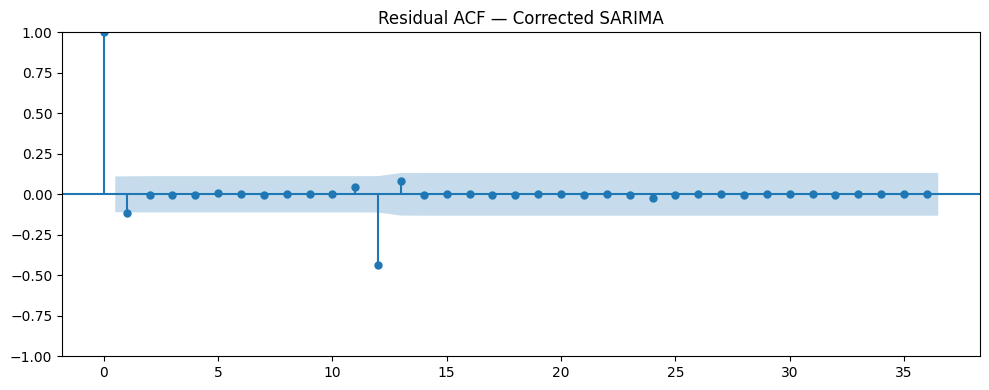

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


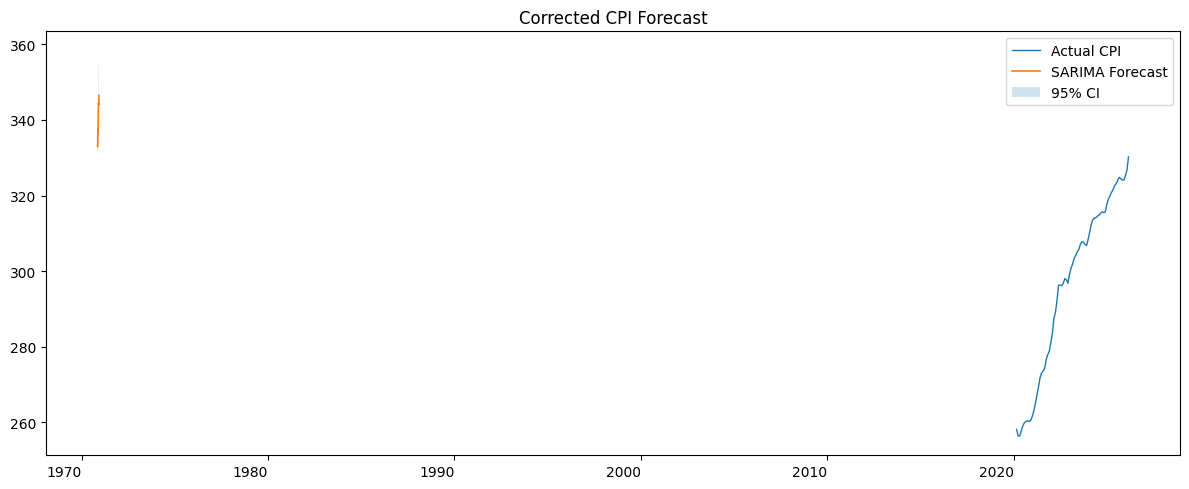


Verification complete.
ADF p-value after first differencing: 0.0805
ADF p-value after first + seasonal differencing: 0.0005
Ljung-Box p-values: [8.46673330e-10 1.97480199e-06]
Residual diagnostics did NOT fully pass. Try another SARIMA specification.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Step 1: Check differencing more carefully
cpi_diff_1 = cpi.diff().dropna()
cpi_diff_1_12 = cpi.diff().diff(12).dropna()

adf_stat_1, adf_p_1, _, _, _, _ = adfuller(cpi_diff_1, autolag='AIC', regression='c')
adf_stat_12, adf_p_12, _, _, _, _ = adfuller(cpi_diff_1_12, autolag='AIC', regression='c')

print("ADF test on first-differenced CPI:")
print(f"  Test statistic: {adf_stat_1:.4f}")
print(f"  P-value: {adf_p_1:.4f}")
print(f"  Conclusion: {'Stationary' if adf_p_1 < 0.05 else 'NON-STATIONARY'}")

print("\nADF test on first + seasonal differenced CPI:")
print(f"  Test statistic: {adf_stat_12:.4f}")
print(f"  P-value: {adf_p_12:.4f}")
print(f"  Conclusion: {'Stationary' if adf_p_12 < 0.05 else 'NON-STATIONARY'}")

# Step 2: Fit seasonal ARIMA for monthly CPI
model = SARIMAX(
    cpi,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print("\nSARIMA model fitted successfully.")
print(f"AIC: {result.aic:.2f}")
print(f"BIC: {result.bic:.2f}")

# Step 3: Residual diagnostics
resid = result.resid.dropna()
lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)

print("\nLjung-Box test results:")
print(lb)

# Residual ACF plot
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=36, ax=ax, alpha=0.05)
ax.set_title("Residual ACF — Corrected SARIMA")
plt.tight_layout()
plt.show()

# Step 4: Forecast
forecast_horizon = 24
forecast_obj = result.get_forecast(steps=forecast_horizon)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-72:].plot(ax=ax, label='Actual CPI', linewidth=1.0)
forecast_mean.plot(ax=ax, label='SARIMA Forecast', linewidth=1.2)
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label='95% CI'
)
ax.set_title("Corrected CPI Forecast")
ax.legend()
plt.tight_layout()
plt.show()

print("\nVerification complete.")
print(f"ADF p-value after first differencing: {adf_p_1:.4f}")
print(f"ADF p-value after first + seasonal differencing: {adf_p_12:.4f}")
print("Ljung-Box p-values:", lb["lb_pvalue"].values)

if (lb["lb_pvalue"] > 0.05).all():
    print("Residual diagnostics passed.")
else:
    print("Residual diagnostics did NOT fully pass. Try another SARIMA specification.")

---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

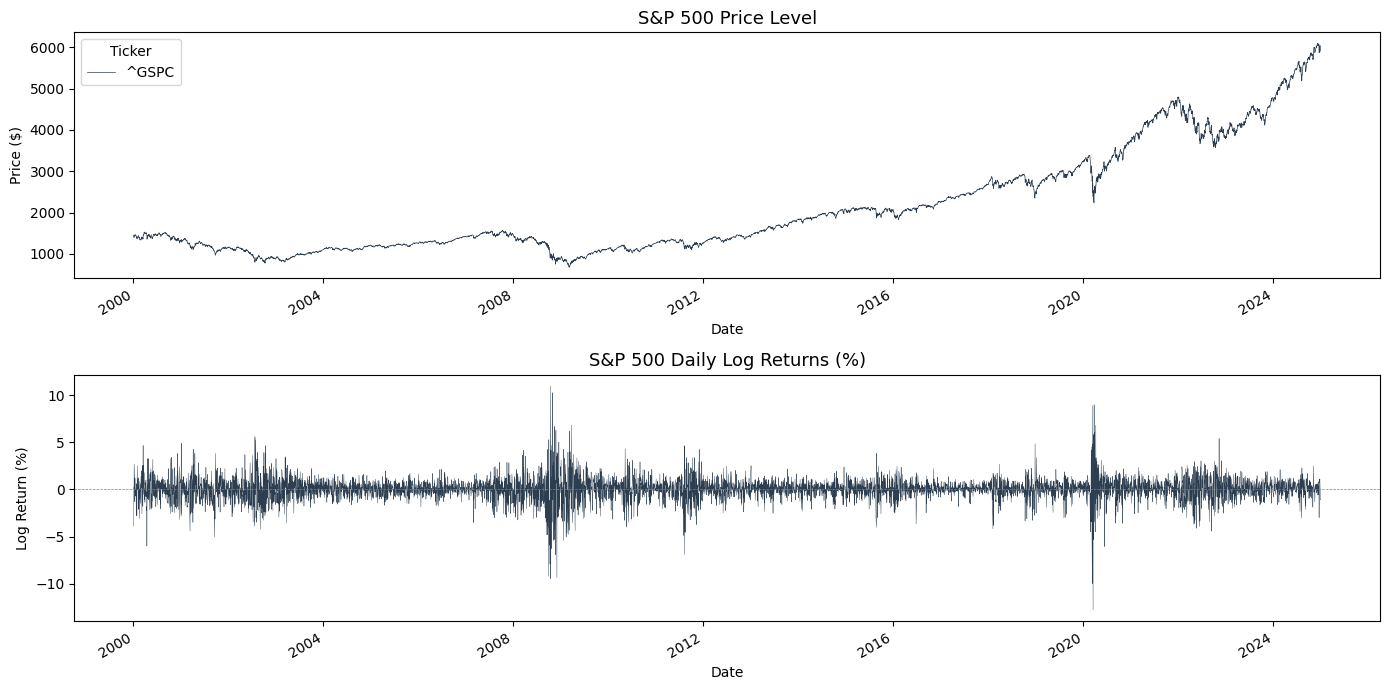

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [ ]:
garch_spec = arch_model(
    returns,
    mean='Constant',
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

params = garch_result.params
alpha1 = params['alpha[1]']
beta1 = params['beta[1]']
persistence = alpha1 + beta1

print(f"\nalpha[1] = {alpha1:.4f}")
print(f"beta[1]  = {beta1:.4f}")
print(f"alpha + beta = {persistence:.4f}")

assert persistence < 1, "GARCH stationarity condition failed: alpha + beta must be < 1."

if 0 < persistence < 1:
    half_life = np.log(0.5) / np.log(persistence)
    print(f"Half-life of volatility shocks: {half_life:.2f} trading days")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8655.88
Distribution:                  Normal   AIC:                           17319.8
Method:            Maximum Likelihood   BIC:                           17346.8
                                        No. Observations:                 6287
Date:                Mon, Apr 20 2026   Df Residuals:                     6286
Time:                        03:33:09   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0615  1.029e-02      5.979  2.239e-09 [4.

### GARCH(1,1) interpretation

The GARCH(1,1) model captures volatility clustering in S&P 500 returns by modeling conditional variance using past shocks and past variance. The persistence measure is `alpha[1] + beta[1]`. Since this sum is less than 1, the variance process is stationary, meaning volatility shocks decay over time rather than persisting forever.

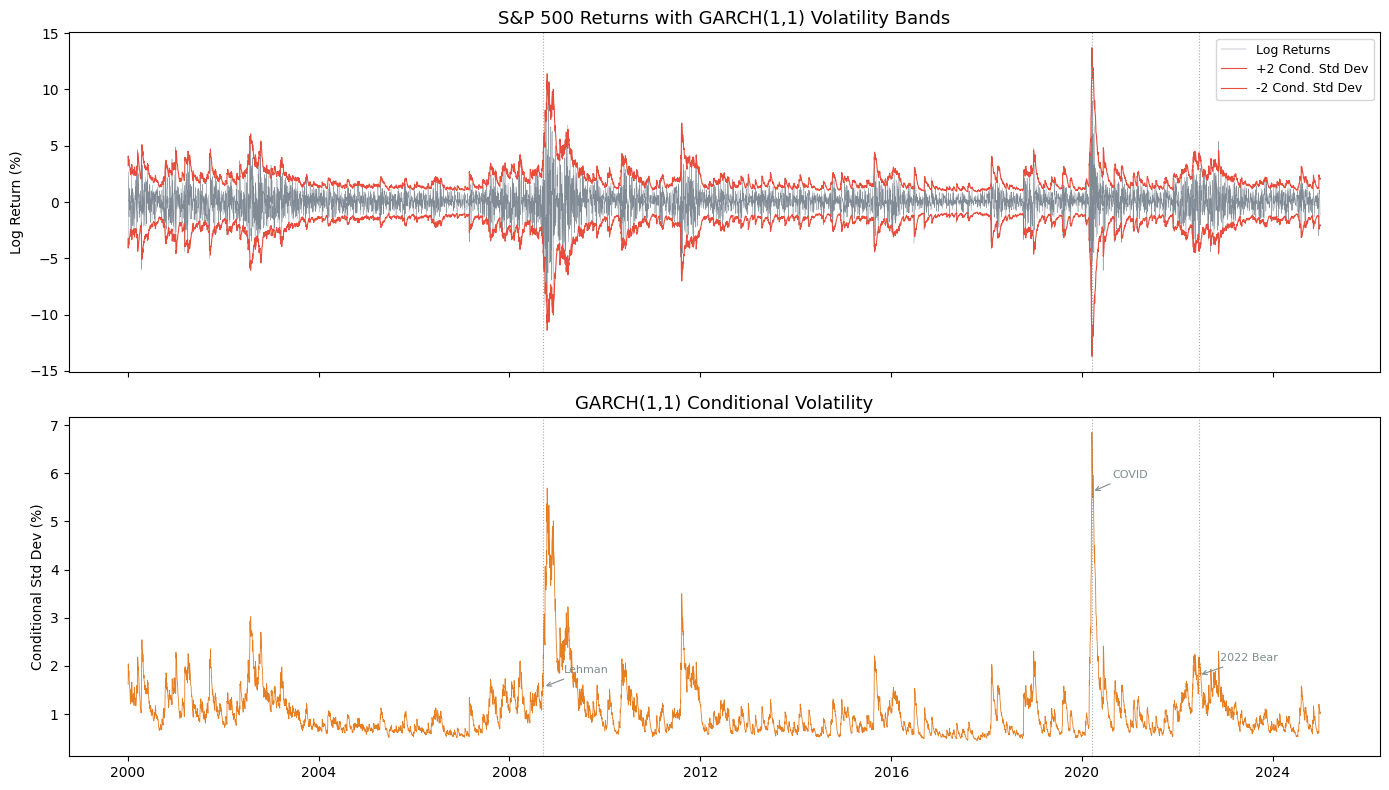

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [ ]:
import os

os.makedirs("src", exist_ok=True)

module_code = '''
"""
forecast_evaluation.py — Forecast Evaluation & Backtesting Module

Reusable functions for computing MASE and running expanding-window
backtests on time series forecasting models.

Author: Drago Zhao
Course: ECON 5200, Lab 21
"""

from __future__ import annotations

import numpy as np
import pandas as pd
from typing import Callable, Any


def compute_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    insample: np.ndarray,
    m: int = 1
) -> float:
    """Compute Mean Absolute Scaled Error."""
    actual = np.asarray(actual, dtype=float).ravel()
    forecast = np.asarray(forecast, dtype=float).ravel()
    insample = np.asarray(insample, dtype=float).ravel()

    if len(actual) == 0 or len(forecast) == 0 or len(insample) == 0:
        raise ValueError("Inputs must be non-empty.")
    if len(actual) != len(forecast):
        raise ValueError("actual and forecast must have the same length.")
    if m < 1:
        raise ValueError("m must be >= 1.")
    if len(insample) <= m:
        raise ValueError("insample length must be greater than m.")

    mae_model = np.mean(np.abs(actual - forecast))
    mae_naive = np.mean(np.abs(insample[m:] - insample[:-m]))

    if np.isclose(mae_naive, 0):
        raise ValueError("Naive MAE is zero, so MASE is undefined.")

    return float(mae_model / mae_naive)


def backtest_expanding_window(
    series: pd.Series,
    model_fn: Callable[[pd.Series], Any],
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Run expanding-window backtesting for a forecasting model."""
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series.")
    if min_train < 1 or horizon < 1 or step < 1:
        raise ValueError("min_train, horizon, and step must all be >= 1.")
    if len(series) < min_train + horizon:
        raise ValueError("Series is too short for the requested backtest.")

    y = series.dropna().copy()
    results = []

    def extract_forecast(fitted_model, horizon):
        if hasattr(fitted_model, "get_forecast"):
            pred = fitted_model.get_forecast(steps=horizon).predicted_mean
            return np.asarray(pred, dtype=float).ravel()
        elif hasattr(fitted_model, "forecast"):
            pred = fitted_model.forecast(steps=horizon)
            return np.asarray(pred, dtype=float).ravel()
        else:
            return np.asarray(fitted_model, dtype=float).ravel()

    for train_end in range(min_train, len(y) - horizon + 1, step):
        train = y.iloc[:train_end]
        test = y.iloc[train_end:train_end + horizon]

        fitted_model = model_fn(train)
        forecast = extract_forecast(fitted_model, horizon)

        if len(forecast) != len(test):
            raise ValueError("Forecast length does not match test length.")

        actual = test.to_numpy(dtype=float)
        mae = float(np.mean(np.abs(actual - forecast)))
        rmse = float(np.sqrt(np.mean((actual - forecast) ** 2)))

        try:
            mase = compute_mase(actual, forecast, train.to_numpy(dtype=float), m=1)
        except ValueError:
            mase = np.nan

        results.append({
            "train_end": train.index[-1],
            "test_start": test.index[0],
            "test_end": test.index[-1],
            "mae": mae,
            "rmse": rmse,
            "mase": mase,
            "n_test": len(test)
        })

    return pd.DataFrame(results)
'''

with open("src/forecast_evaluation.py", "w", encoding="utf-8") as f:
    f.write(module_code)

print("src/forecast_evaluation.py created successfully.")

src/forecast_evaluation.py created successfully.


In [ ]:
from src.forecast_evaluation import compute_mase, backtest_expanding_window

print("Import successful.")

Import successful.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from src.forecast_evaluation import backtest_expanding_window

def model_fn(train_series):
    model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model.fit(disp=False)

bt = backtest_expanding_window(
    cpi,
    model_fn=model_fn,
    min_train=120,
    horizon=12,
    step=12
)

print(bt.head())
print("\nAverage MAE :", bt["mae"].mean())
print("Average RMSE:", bt["rmse"].mean())
print("Average MASE:", bt["mase"].mean())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

   train_end test_start   test_end       mae      rmse      mase  n_test
0 2009-12-01 2010-01-01 2010-12-01  2.542530  2.931238  3.376082      12
1 2010-12-01 2011-01-01 2011-12-01  0.613549  0.706566  0.861698      12
2 2011-12-01 2012-01-01 2012-12-01  0.565973  0.694659  0.788171      12
3 2012-12-01 2013-01-01 2013-12-01  1.145216  1.244962  1.582227      12
4 2013-12-01 2014-01-01 2014-12-01  0.912676  1.411421  1.288165      12

Average MAE : 2.1618809291094903
Average RMSE: 2.4857880213358605
Average MASE: 3.0065122993233047


---

## Challenge: Block Bootstrap Forecast Intervals

Standard ARIMA confidence intervals assume normally distributed, i.i.d. residuals.
When residuals exhibit volatility clustering or heavy tails, these intervals
can be **too narrow**. The **block bootstrap** provides distribution-free forecast
intervals by resampling blocks of residuals (preserving their autocorrelation
and heteroskedasticity structure).

**Algorithm:**
1. Fit your SARIMA model and extract residuals
2. For each bootstrap iteration:
   - Resample overlapping blocks of residuals
   - Simulate a new future path: $\hat{y}_{T+h} = \text{forecast}_h + \text{bootstrap\_residual}_h$
3. Collect all bootstrap paths and compute percentile-based intervals

In [ ]:
# -----------------------------------------------------------
# CHALLENGE — Block bootstrap forecast intervals
# Fill in the blanks (___) to complete the implementation
# -----------------------------------------------------------

def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 500,
    block_size: int = 6,
    alpha: float = 0.05
):
    """Generate block-bootstrap forecast intervals.

    Args:
        model_result: Fitted SARIMAX result object
        horizon: Number of steps to forecast
        n_bootstrap: Number of bootstrap replications
        block_size: Block length for moving block bootstrap
        alpha: Significance level (0.05 = 95% CI)

    Returns:
        dict with 'mean', 'lower', 'upper', 'paths' keys
    """
    # Get the point forecast
    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values

    # Extract residuals from the fitted model
    residuals = model_result.resid.values
    n_resid = len(residuals)

    # Store bootstrap forecast paths
    boot_paths = np.zeros((n_bootstrap, ___))  # FILL IN: what is the second dimension?

    for b in range(n_bootstrap):
        # Moving block bootstrap on residuals
        boot_resid = np.zeros(horizon)
        idx = 0
        while idx < ___:  # FILL IN: loop until we have enough residuals
            start = np.random.randint(0, ___)  # FILL IN: valid block start range
            block = residuals[start:start + block_size]
            end = min(idx + block_size, horizon)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Bootstrap path = point forecast + resampled residuals
        boot_paths[b, :] = ___ + ___  # FILL IN: combine forecast and residuals

    # Percentile-based confidence intervals
    lower = np.percentile(boot_paths, 100 * (alpha / 2), axis=___)
    upper = np.percentile(boot_paths, 100 * (1 - alpha / 2), axis=___)

    return {
        'mean': forecast_mean,
        'lower': lower,
        'upper': upper,
        'paths': boot_paths
    }


# Usage (uncomment after fixing Part 2):
# boot_ci = block_bootstrap_forecast(sarima_result, horizon=24, n_bootstrap=500)
#
# fig, ax = plt.subplots(figsize=(12, 5))
# cpi[-60:].plot(ax=ax, label='Actual', color='#2c3e50')
# forecast_idx = pd.date_range(cpi.index[-1], periods=25, freq='MS')[1:]
# ax.plot(forecast_idx, boot_ci['mean'], color='#e74c3c', label='Forecast')
# ax.fill_between(forecast_idx, boot_ci['lower'], boot_ci['upper'],
#                 alpha=0.2, color='#3498db', label='95% Block Bootstrap CI')
# ax.set_title('SARIMA Forecast with Block Bootstrap Intervals', fontsize=13)
# ax.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 500,
    block_size: int = 6,
    alpha: float = 0.05
):
    """Generate block-bootstrap forecast intervals."""
    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values

    residuals = np.asarray(model_result.resid)
    residuals = residuals[~np.isnan(residuals)]
    n_resid = len(residuals)

    boot_paths = np.zeros((n_bootstrap, horizon))

    max_start = n_resid - block_size + 1
    if max_start <= 0:
        raise ValueError("block_size is too large for the number of residuals.")

    for b in range(n_bootstrap):
        sampled = []

        while len(sampled) < horizon:
            start = np.random.randint(0, max_start)
            block = residuals[start:start + block_size]
            sampled.extend(block.tolist())

        sampled = np.array(sampled[:horizon])
        boot_paths[b, :] = forecast_mean + sampled

    lower = np.percentile(boot_paths, 100 * (alpha / 2), axis=0)
    upper = np.percentile(boot_paths, 100 * (1 - alpha / 2), axis=0)

    return {
        "mean": forecast_mean,
        "lower": lower,
        "upper": upper,
        "paths": boot_paths
    }

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.